# Phần 1: Tiền xử lý dữ liệu (Data Preprocessing)

## 1.1. Tải dữ liệu

In [95]:
# Import thư viện
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [96]:
# Thiết lập đường dẫn thư mục chứa dữ liệu đầu vào
DATA_DIR = 'dataset/'

> `Sales`: dữ liệu doanh thu (huấn luyện)

In [97]:
df_sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[us]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 90.0 KB


> `Products`: Danh mục sản phẩm

In [98]:
df_products = pd.read_csv(DATA_DIR + 'products.csv')
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB


> `Customers`: Thông tin khách hàng

In [99]:
df_customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          121930 non-null  int64         
 1   zip                  121930 non-null  int64         
 2   city                 121930 non-null  str           
 3   signup_date          121930 non-null  datetime64[us]
 4   gender               121930 non-null  str           
 5   age_group            121930 non-null  str           
 6   acquisition_channel  121930 non-null  str           
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 6.5 MB


> `Promotions`: Các chiến dịch khuyến mãi

In [100]:
df_promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date','end_date'])
df_promotions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     str           
 1   promo_name           50 non-null     str           
 2   promo_type           50 non-null     str           
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[us]
 5   end_date             50 non-null     datetime64[us]
 6   applicable_category  10 non-null     str           
 7   promo_channel        50 non-null     str           
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(5)
memory usage: 4.0 KB


> `Geography`: Danh sách mã bưu chính các vùng

In [101]:
df_geography = pd.read_csv(DATA_DIR + 'geography.csv')
df_geography.info()

<class 'pandas.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   zip       39948 non-null  int64
 1   city      39948 non-null  str  
 2   region    39948 non-null  str  
 3   district  39948 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.2 MB


> `Orders`: thông tin đơn hàng

In [102]:
df_orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[us]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  str           
 5   payment_method  646945 non-null  str           
 6   device_type     646945 non-null  str           
 7   order_source    646945 non-null  str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 39.5 MB


> `Order Items`: Chi tiết từng dòng sản phẩm trong đơn

In [103]:
df_order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  str    
 6   promo_id_2       206 non-null     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 38.2 MB


> `Payments`: Thông tin thanh toán (tương ứng 1:1 với đơn hàng)

In [104]:
df_payments = pd.read_csv(DATA_DIR + 'payments.csv')
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  str    
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 19.7 MB


> `Shipments`: Thông tin vận chuyển

In [105]:
df_shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
df_shipments.info()

<class 'pandas.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       566067 non-null  int64         
 1   ship_date      566067 non-null  datetime64[us]
 2   delivery_date  566067 non-null  datetime64[us]
 3   shipping_fee   566067 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(1)
memory usage: 17.3 MB


> `Returns`: Các sản phẩm trả lại

In [106]:
df_returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date'])
df_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  str           
 1   order_id         39939 non-null  int64         
 2   product_id       39939 non-null  int64         
 3   return_date      39939 non-null  datetime64[us]
 4   return_reason    39939 non-null  str           
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 2.1 MB


> `Reviews`: Đánh giá sản phẩm sau giao hàng

In [107]:
df_reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date'])
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   review_id     113551 non-null  str           
 1   order_id      113551 non-null  int64         
 2   product_id    113551 non-null  int64         
 3   customer_id   113551 non-null  int64         
 4   review_date   113551 non-null  datetime64[us]
 5   rating        113551 non-null  int64         
 6   review_title  113551 non-null  str           
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 6.1 MB


> `Inventory`: Ảnh chụp tồn kho cuối tháng

In [108]:
df_inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])
df_inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[us]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  str           
 13  category           60247 non-null  str           
 14  segment          

> `Web Traffic`: Lưu lượng truy cập website mỗi ngày

In [109]:
df_web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
df_web_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[us]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 199.8 KB


## 1.2. Làm sạch và kiểm định chất lượng dữ liệu

In [110]:
# Gom tất cả các bảng vào một dictionary để dễ dàng quét lỗi
all_dataframes = {
    'sales': df_sales, 'products': df_products, 'customers': df_customers, 'promotions': df_promotions, 'geography': df_geography, 'orders': df_orders, 'order_items': df_order_items, 'payments': df_payments, 'shipments': df_shipments, 'returns': df_returns, 'reviews': df_reviews, 'inventory': df_inventory, 'web_traffic': df_web_traffic
}

**Tính đầy đủ (Completeness)**

In [111]:
# Quét qua từng bảng để tìm lỗi (nếu có)
for name, df in all_dataframes.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    total   = len(df)
    if not missing.empty:
        print(f"\n[!] Bảng '{name}' ({total:,} dòng) — CÓ dữ liệu bị thiếu:")
        for col, n in missing.items():
            pct = n / total * 100
            bar = '█' * int(pct / 5)
            print(f"      {col:<30} {n:>8,}  ({pct:5.1f}%)  {bar}")
    else:
        print(f"[✓] Bảng '{name}' ({total:,} rows)")

[✓] Bảng 'sales' (3,833 rows)
[✓] Bảng 'products' (2,412 rows)
[✓] Bảng 'customers' (121,930 rows)

[!] Bảng 'promotions' (50 dòng) — CÓ dữ liệu bị thiếu:
      applicable_category                  40  ( 80.0%)  ████████████████
[✓] Bảng 'geography' (39,948 rows)
[✓] Bảng 'orders' (646,945 rows)

[!] Bảng 'order_items' (714,669 dòng) — CÓ dữ liệu bị thiếu:
      promo_id                        438,353  ( 61.3%)  ████████████
      promo_id_2                      714,463  (100.0%)  ███████████████████
[✓] Bảng 'payments' (646,945 rows)
[✓] Bảng 'shipments' (566,067 rows)
[✓] Bảng 'returns' (39,939 rows)
[✓] Bảng 'reviews' (113,551 rows)
[✓] Bảng 'inventory' (60,247 rows)
[✓] Bảng 'web_traffic' (3,652 rows)


*Nhận xét:*
- Cột `applicable_category` của bảng 'promotions' cho phép `null` nếu áp dụng tất cả danh mục $\rightarrow$ Không cần phải xử lý.
- Cột `promo_id` và `promo_id_2` của bảng 'order_items' cho phép `null` $\rightarrow$ không cần phải xử lý.

**Tính chính xác (Accuracy)**

In [112]:
# Kiểm tra giá trị âm (nếu có)
for name in ['sales', 'products', 'order_items', 'payments', 'shipments', 'returns', 'inventory', 'web_traffic']:
    print(f"\n>> Thống kê bảng '{name}':")
    display(all_dataframes[name].describe())


>> Thống kê bảng 'sales':


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06



>> Thống kê bảng 'products':


,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000



>> Thống kê bảng 'order_items':


...

,order_id,product_id,return_date,return_quantity,refund_amount
count,39939.000000,39939.000000,39939,39939.000000,39939.000000
mean,409061.984176,1244.232730,2016-11-11 22:20:33.621272,2.743834,12784.458964
min,2.000000,3.000000,2012-07-11 00:00:00,1.000000,458.810000
25%,202651.000000,702.000000,2014-08-05 00:00:00,1.000000,3573.395000
50%,404254.000000,992.000000,2016-07-06 00:00:00,2.000000,7888.880000
75%,615620.000000,2048.000000,2018-08-08 00:00:00,4.000000,16881.990000
max,833351.000000,2412.000000,2022-12-31 00:00:00,8.000000,160937.940000
std,240063.904576,691.747822,NaN,1.828260,14092.150154



>> Thống kê bảng 'inventory':


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,2017-10-08 17:36:29.924809,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
min,2012-07-31 00:00:00,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,2015-03-31 00:00:00,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,2017-09-30 00:00:00,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,2020-04-30 00:00:00,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2022-12-31 00:00:00,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000
std,NaN,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629



>> Thống kê bảng 'web_traffic':


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,2017-12-31 12:00:00,25041.768072,19031.404436,108615.224535,0.004487,210.283242
min,2013-01-01 00:00:00,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,2015-07-02 18:00:00,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,2017-12-31 12:00:00,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,2020-07-01 06:00:00,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,2022-12-31 00:00:00,50947.000000,40430.000000,275560.000000,0.005800,319.900000
std,NaN,9422.609335,7237.953062,44472.055524,0.000753,63.771711


*Nhận xét:* Các dữ liệu đều không có sai số logic về tiền tệ hay số lượng.

**Tính hợp lệ (Validity)**

In [113]:
# Dữ liệu dạng nhãn
categorical_map = {
    'customers': ['gender', 'age_group'],
    'products': ['category', 'segment'],
    'orders': ['order_status', 'payment_method', 'device_type']
}
for name, cols in categorical_map.items():
    for col in cols:
        print(f"Bảng {name} - Cột {col}: {all_dataframes[name][col].unique()}")

Bảng customers - Cột gender: <StringArray>
['Female', 'Male', 'Non-binary']
Length: 3, dtype: str
Bảng customers - Cột age_group: <StringArray>
['35-44', '45-54', '18-24', '55+', '25-34']
Length: 5, dtype: str
Bảng products - Cột category: <StringArray>
['Streetwear', 'Casual', 'Outdoor', 'GenZ']
Length: 4, dtype: str
Bảng products - Cột segment: <StringArray>
[   'Everyday', 'Performance',    'Balanced',    'Standard', 'All-weather',
     'Premium',      'Trendy',  'Activewear']
Length: 8, dtype: str
Bảng orders - Cột order_status: <StringArray>
['delivered', 'returned', 'shipped', 'cancelled', 'paid', 'created']
Length: 6, dtype: str
Bảng orders - Cột payment_method: <StringArray>
['credit_card', 'cod', 'paypal', 'apple_pay', 'bank_transfer']
Length: 5, dtype: str
Bảng orders - Cột device_type: <StringArray>
['desktop', 'mobile', 'tablet']
Length: 3, dtype: str


In [114]:
# Ràng buộc trong 'products': cogs < price
invalid_products = df_products[df_products['cogs'] >= df_products['price']]
print("Số sản phẩm không hợp lệ:", len(invalid_products))

Số sản phẩm không hợp lệ: 0


*Nhận xét:* Các giá trị trong các cột phân loại cho thấy dữ liệu đã được chuẩn hóa cực kỳ tốt, ví dụ như `gender` và `age_group`: các nhóm được chia rõ ràng, không có giá trị rác.

**Tính nhất quán (Consistency)**

In [115]:
# Kiểm tra lỗi phân tích ngày (NaT)
for name, df in all_dataframes.items():
    date_cols = df.select_dtypes(include=['datetime64']).columns
    for col in date_cols:
        nat_count = df[col].isna().sum()
        if nat_count > 0: print(f"[!] {name}.{col} có {nat_count} dòng lỗi định dạng ngày!")
print('[✓] Không có lỗi định dạng ngày.')

[✓] Không có lỗi định dạng ngày.


In [116]:
# Kiểm tra tính toàn vẹn của Khóa ngoại
fk_relationships = [
    (df_customers, 'zip', df_geography, 'zip'),
    (df_orders, 'customer_id', df_customers, 'customer_id'),
    (df_orders, 'zip', df_geography, 'zip'),
    (df_order_items, 'order_id', df_orders, 'order_id'),
    (df_order_items, 'product_id', df_products, 'product_id'),
    (df_order_items, 'promo_id', df_promotions, 'promo_id'),
    (df_order_items, 'promo_id_2', df_promotions, 'promo_id'),
    (df_payments, 'order_id', df_orders, 'order_id'),
    (df_shipments, 'order_id', df_orders, 'order_id'),
    (df_returns, 'order_id', df_orders, 'order_id'),
    (df_returns, 'product_id', df_products, 'product_id'),
    (df_reviews, 'order_id', df_orders, 'order_id'),
    (df_reviews, 'product_id', df_products, 'product_id'),
    (df_reviews, 'customer_id', df_customers, 'customer_id'),
    (df_inventory, 'product_id', df_products, 'product_id')
]
for df1, col1, df2, col2 in fk_relationships:
    orphans = df1[~df1[col1].isin(df2[col2])][col1].nunique()
    print(f"Liên kết: {col1} -> {col2} | Số bản ghi lỗi: {orphans}")

Liên kết: zip -> zip | Số bản ghi lỗi: 0
Liên kết: customer_id -> customer_id | Số bản ghi lỗi: 0
Liên kết: zip -> zip | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: promo_id -> promo_id | Số bản ghi lỗi: 0
Liên kết: promo_id_2 -> promo_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: customer_id -> customer_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0


*Nhận xét:* Dữ liệu không bị trùng lặp, đảm bảo các tính toán không bị thổi phồng.

**Tính duy nhất (Uniqueness)**

In [117]:
for name, df in all_dataframes.items():
    dupes = df.duplicated().sum()
    print(f"Bảng '{name}': {dupes} dòng trùng lặp.")

Bảng 'sales': 0 dòng trùng lặp.
Bảng 'products': 0 dòng trùng lặp.
Bảng 'customers': 0 dòng trùng lặp.
Bảng 'promotions': 0 dòng trùng lặp.
Bảng 'geography': 0 dòng trùng lặp.
Bảng 'orders': 0 dòng trùng lặp.
Bảng 'order_items': 0 dòng trùng lặp.
Bảng 'payments': 0 dòng trùng lặp.
Bảng 'shipments': 0 dòng trùng lặp.
Bảng 'returns': 0 dòng trùng lặp.
Bảng 'reviews': 0 dòng trùng lặp.
Bảng 'inventory': 0 dòng trùng lặp.
Bảng 'web_traffic': 0 dòng trùng lặp.


*Nhận xét:* Các bộ dữ liệu ở mỗi cơ sở dữ liệu là duy nhất.

## 1.3. Hợp nhất dữ liệu và kỹ thuật tạo đặc trưng

In [118]:
# ── Bảng giao dịch chi tiết ────────────────────────────────────────────
oi = df_order_items.copy()
oi['revenue'] = oi['quantity'] * oi['unit_price'] - oi['discount_amount'].fillna(0)

# Gắn thông tin sản phẩm
oi_full = oi.merge(
    df_products[['product_id','category','segment','size','color','price','cogs']],
    on='product_id', how='left'
)

# Gắn thông tin đơn hàng + địa lý + khách hàng
orders_geo = df_orders.merge(
    df_geography[['zip','region','city','district']], on='zip', how='left'
)
orders_geo = orders_geo.merge(
    df_customers[['customer_id','gender','age_group','acquisition_channel']],
    on='customer_id', how='left'
)
oi_full = oi_full.merge(
    orders_geo[['order_id','order_date','order_status','region','city',
                'gender','age_group','acquisition_channel',
                'device_type','order_source']],
    on='order_id', how='left'
)
oi_full['year']         = oi_full['order_date'].dt.year
oi_full['month']        = oi_full['order_date'].dt.month
oi_full['gross_profit'] = oi_full['revenue'] - oi_full['quantity'] * oi_full['cogs']

# ── Sales level ─────────────────────────────────────────────────────────
df_sales['year']        = df_sales['Date'].dt.year
df_sales['month']       = df_sales['Date'].dt.month
df_sales['GrossProfit'] = df_sales['Revenue'] - df_sales['COGS']
df_sales['GrossMargin'] = df_sales['GrossProfit'] / df_sales['Revenue'] * 100

# ── Thời gian giao hàng ─────────────────────────────────────────────────
df_shipments['delivery_days'] = (
    df_shipments['delivery_date'] - df_shipments['ship_date']
).dt.days

print(f'oi_full     : {oi_full.shape}')
print(f'orders_geo  : {orders_geo.shape}')
print('Dữ liệu sẵn sàng cho EDA.')

oi_full     : (714669, 26)
orders_geo  : (646945, 14)
Dữ liệu sẵn sàng cho EDA.


# Phần 2: Visualization & EDA

## 2.1. Thiết lập thư viện và phong cách

In [119]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import matplotlib.patheffects as pe
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.color'       : 'white',
    'grid.linewidth'   : 1.2,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'font.size'        : 10,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Màu sắc ────────────────────────────────────────────────────────────
BLUE   = '#378ADD'
GREEN  = '#1D9E75'
AMBER  = '#BA7517'
RED    = '#E24B4A'
PURPLE = '#534AB7'
GRAY   = '#888780'
CORAL  = '#D85A30'
PINK   = '#D4537E'
TEAL   = '#0F6E56'
PINK_MAIN   = '#FF9AA2'   # hồng pastel
PINK_DARK   = '#E75480'   # hồng đậm (trend)
YELLOW_SOFT = '#FFD166'   # vàng nhẹ
YELLOW_HL   = '#FFB347'   # vàng highlight
CORAL_PEAK  = '#FF6F61'   # cam-hồng (peak)
TEXT_GRAY   = '#6D6875'   # xám tím nhẹ
BG_COLOR    = '#FFF7F0'   # nền kem

print('Setup hoàn tất!')

Setup hoàn tất!


## 2.2. Descriptive: What happened?

**Tổng quan doanh thu trong 10 năm và chỉ số mùa vụ**

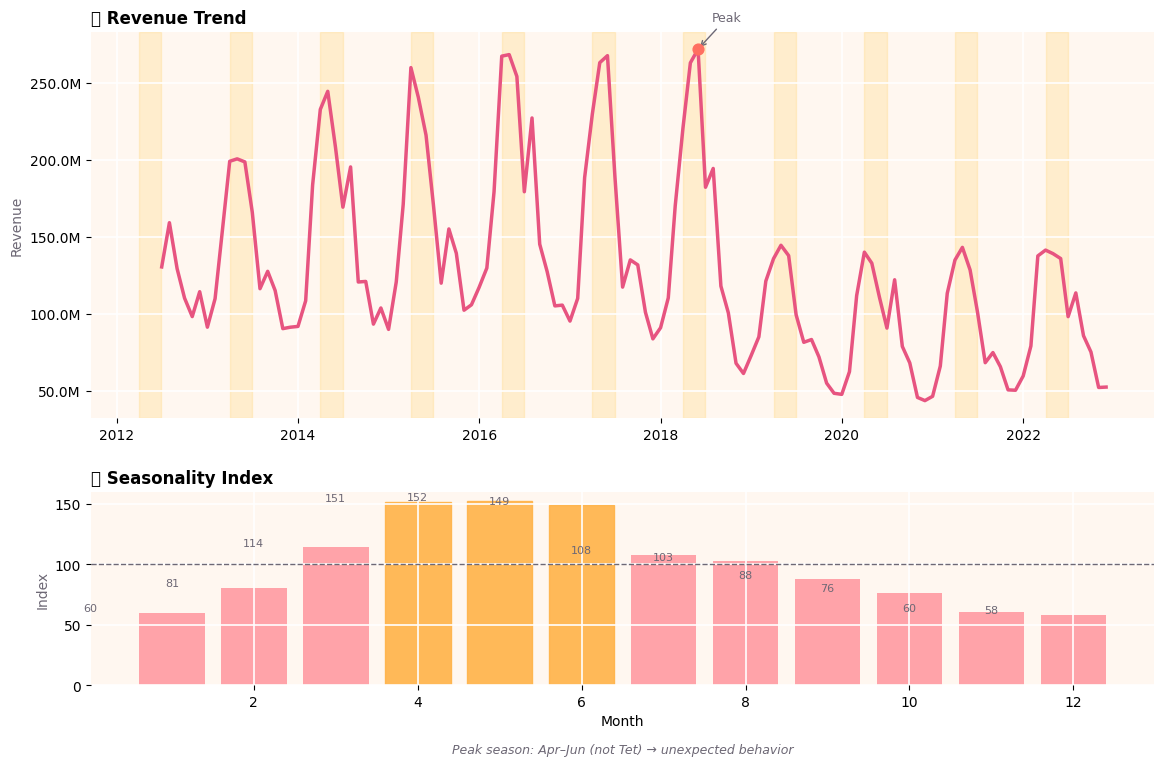

In [120]:
# ==============================
# PREP DATA
# ==============================

# monthly sales (Date nằm ở index)
monthly_sales = df_sales.groupby(df_sales['Date'].dt.to_period('M')).agg(
    Revenue=('Revenue','sum'),
    COGS=('COGS','sum')
)

monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.reset_index().rename(columns={'Date':'Month'})

# seasonality
seasonality_df = df_sales.groupby(df_sales['Date'].dt.month)['Revenue'].mean().reset_index()
seasonality_df.columns = ['month', 'Revenue']
seasonality_df['seasonality_index'] = seasonality_df['Revenue'] / seasonality_df['Revenue'].mean() * 100


# ==============================
# PLOT
# ==============================
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={'height_ratios': [2, 1]}
)

# nền
for ax in axes:
    ax.set_facecolor(BG_COLOR)

# ==============================
# PANEL 1 — TREND
# ==============================
ax = axes[0]

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Revenue',
    ax=ax,
    color=PINK_DARK,
    linewidth=2.5
)

# highlight Apr–Jun
for year in monthly_sales['Month'].dt.year.unique():
    ax.axvspan(
        pd.Timestamp(f'{year}-04-01'),
        pd.Timestamp(f'{year}-06-30'),
        color=YELLOW_SOFT,
        alpha=0.25
    )

# format trục
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title('🌸 Revenue Trend', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Revenue', color=TEXT_GRAY)

# peak point (FIX)
peak_idx = monthly_sales['Revenue'].idxmax()
peak_x = monthly_sales.loc[peak_idx, 'Month']
peak_y = monthly_sales.loc[peak_idx, 'Revenue']

ax.scatter(peak_x, peak_y, color=CORAL_PEAK, s=60, zorder=5)

ax.annotate(
    'Peak',
    xy=(peak_x, peak_y),
    xytext=(10, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=TEXT_GRAY),
    fontsize=9,
    color=TEXT_GRAY
)

# ==============================
# PANEL 2 — SEASONALITY
# ==============================
ax2 = axes[1]

bars = ax2.bar(
    seasonality_df['month'],
    seasonality_df['seasonality_index'],
    color=PINK_MAIN,
    alpha=0.9
)

# highlight T4–T6
for i, m in enumerate(seasonality_df['month']):
    if m in [4, 5, 6]:
        bars[i].set_color(YELLOW_HL)

# baseline
ax2.axhline(100, color=TEXT_GRAY, linestyle='--', linewidth=1)

ax2.set_title('🌼 Seasonality Index', loc='left')
ax2.set_xlabel('Month')
ax2.set_ylabel('Index', color=TEXT_GRAY)

# label
for i, v in enumerate(seasonality_df['seasonality_index']):
    ax2.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=8, color=TEXT_GRAY)

# insight
ax2.text(
    0.5, -0.35,
    'Peak season: Apr–Jun (not Tet) → unexpected behavior',
    transform=ax2.transAxes,
    ha='center',
    fontsize=9,
    color=TEXT_GRAY,
    style='italic'
)

plt.tight_layout(pad=2.0)
plt.show()

## 2.3. Diagnostic: Why did it happen?

**Cơ cấu doanh thu và biên lợi nhuận theo ngành hàng**

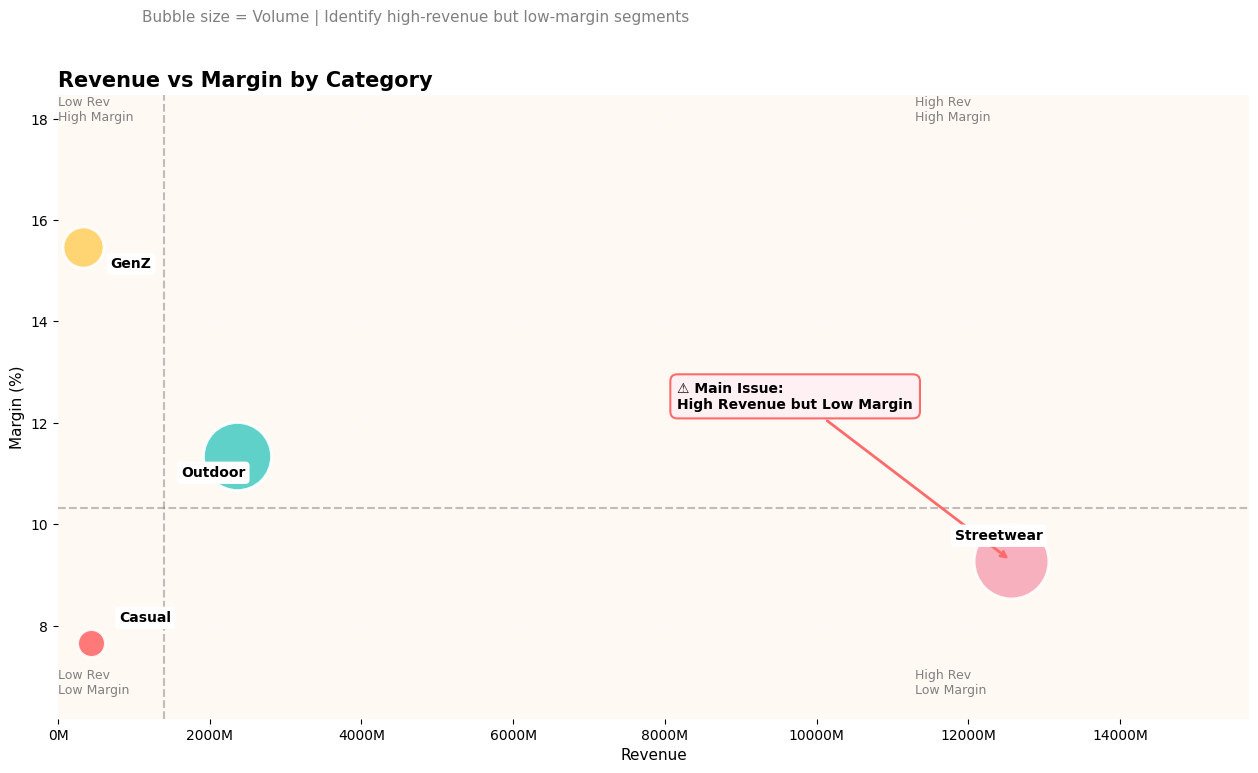

In [121]:
# ==============================
# 1. PREP DATA
# ==============================
cat_perf = oi_full.groupby('category').agg(
    Revenue=('revenue','sum'),
    Profit=('gross_profit','sum'),
    Volume=('quantity','sum')
).reset_index()

cat_perf['Margin'] = cat_perf['Profit'] / cat_perf['Revenue'] * 100

# ==============================
# 2. SCALE BUBBLE SIZE
# ==============================
size_scale = (cat_perf['Volume'] - cat_perf['Volume'].min()) / \
             (cat_perf['Volume'].max() - cat_perf['Volume'].min())

cat_perf['bubble_size'] = np.sqrt(size_scale) * 2500 + 400

# ==============================
# 3. AUTO COLOR PALETTE (NO ERROR)
# ==============================
colors_list = ['#FF6B6B', '#FFD166', '#4ECDC4', '#F7A8B8', '#A0AEC0']
palette = dict(zip(cat_perf['category'], colors_list))

# ==============================
# 4. MEDIAN (QUADRANT)
# ==============================
rev_median = cat_perf['Revenue'].median()
margin_median = cat_perf['Margin'].median()

# ==============================
# 5. PLOT
# ==============================
plt.figure(figsize=(13, 8))
ax = plt.gca()
ax.set_facecolor('#FFF9F4')

# quadrant lines
plt.axvline(rev_median, linestyle='--', color='gray', alpha=0.5)
plt.axhline(margin_median, linestyle='--', color='gray', alpha=0.5)

# ==============================
# 6. BUBBLE
# ==============================
for _, row in cat_perf.iterrows():
    plt.scatter(
        row['Revenue'],
        row['Margin'],
        s=row['bubble_size'],
        color=palette[row['category']],
        alpha=0.9,
        edgecolors='white',
        linewidth=2,
        zorder=3
    )

# ==============================
# 7. LABEL (ANTI OVERLAP)
# ==============================
for _, row in cat_perf.iterrows():

    # auto offset thông minh
    dx = -40 if row['Revenue'] > rev_median else 20
    dy = -15 if row['Margin'] > margin_median else 15

    plt.annotate(
        row['category'],
        (row['Revenue'], row['Margin']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=10,
        weight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"),
        zorder=4
    )

# ==============================
# 8. HIGHLIGHT KEY INSIGHT
# ==============================
if 'Streetwear' in cat_perf['category'].values:
    sw = cat_perf[cat_perf['category'] == 'Streetwear'].iloc[0]

    plt.annotate(
        '⚠ Main Issue:\nHigh Revenue but Low Margin',
        xy=(sw['Revenue'], sw['Margin']),
        xytext=(sw['Revenue']*0.65, sw['Margin']+3),
        arrowprops=dict(
            arrowstyle='->',
            color='#FF6B6B',
            lw=2
        ),
        fontsize=10,
        weight='bold',
        bbox=dict(
            boxstyle="round,pad=0.5",
            fc="#FFF0F3",
            ec="#FF6B6B",
            linewidth=1.5
        )
    )

# ==============================
# 9. AXIS FORMAT
# ==============================
plt.xlim(0, cat_perf['Revenue'].max() * 1.25)
plt.ylim(cat_perf['Margin'].min() - 1.5, cat_perf['Margin'].max() + 3)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

plt.xlabel('Revenue', fontsize=11)
plt.ylabel('Margin (%)', fontsize=11)

# ==============================
# 10. TITLE
# ==============================
plt.title(
    'Revenue vs Margin by Category',
    fontsize=15,
    weight='bold',
    loc='left'
)

plt.suptitle(
    'Bubble size = Volume | Identify high-revenue but low-margin segments',
    fontsize=11,
    x=0.125,
    ha='left',
    color='gray'
)

# ==============================
# 11. QUADRANT LABEL
# ==============================
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(x_max*0.72, y_max-0.5, 'High Rev\nHigh Margin', fontsize=9, color='gray')
plt.text(x_max*0.72, y_min+0.5, 'High Rev\nLow Margin', fontsize=9, color='gray')
plt.text(x_min+200000, y_max-0.5, 'Low Rev\nHigh Margin', fontsize=9, color='gray')
plt.text(x_min+200000, y_min+0.5, 'Low Rev\nLow Margin', fontsize=9, color='gray')

# ==============================
# 12. CLEAN LOOK
# ==============================
plt.grid(alpha=0.15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout(pad=2.2)
plt.show()

*Nhận xét:*

Biểu đồ bubble cho thấy mối quan hệ giữa doanh thu, biên lợi nhuận và sản lượng bán ra theo từng danh mục sản phẩm. Phân tích theo quadrant chỉ ra rằng Streetwear nằm trong vùng “High Revenue – Low Margin”, chiếm tỷ trọng doanh thu lớn nhất nhưng có biên lợi nhuận thấp nhất, qua đó trở thành nguyên nhân chính khiến lợi nhuận tổng thể không tăng tương ứng với doanh thu. Ngược lại, Outdoor thuộc nhóm có biên lợi nhuận cao hơn dù doanh thu thấp hơn, thể hiện tiềm năng tối ưu cơ cấu sản phẩm. Điều này hàm ý doanh nghiệp cần tập trung cải thiện biên lợi nhuận của Streetwear thông qua tối ưu chi phí hoặc điều chỉnh chiến lược giá.

**Cơ cấu giá trị khách hàng theo phân khúc RFM**

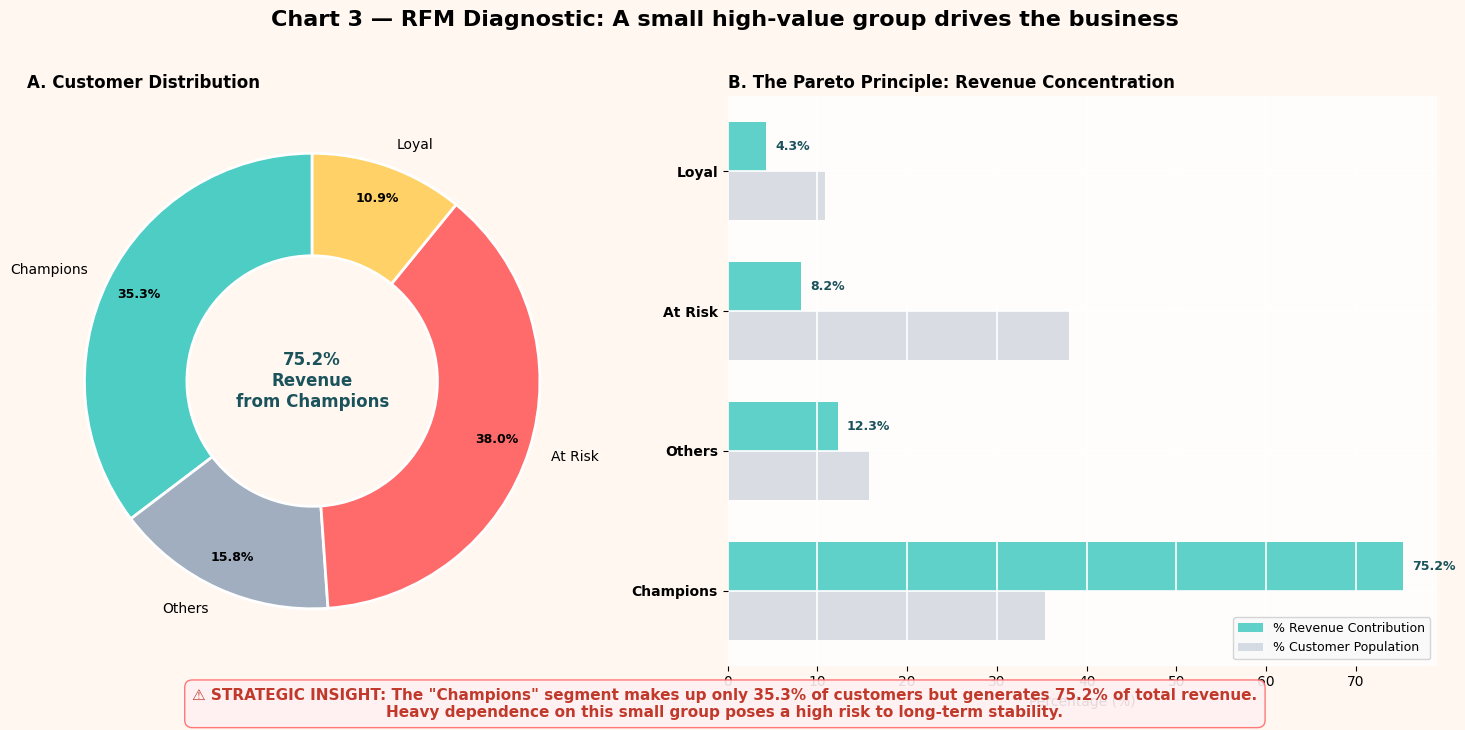

In [122]:
# ==============================
# 1. SCIENTIFIC RFM SCORING
# ==============================
rfm_df = oi_full.copy()
# Merge customer_id into rfm_df
rfm_df = rfm_df.merge(df_orders[['order_id', 'customer_id']], on='order_id', how='left')
rfm_df['order_date'] = pd.to_datetime(rfm_df['order_date'])

snapshot_date = rfm_df['order_date'].max() + pd.Timedelta(days=1)

rfm = rfm_df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('revenue', 'sum')
).reset_index()

# Gán điểm từ 1-4 dựa trên Quartiles (Rank xử lý trùng lặp)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)

# ==============================
# 2. STRATEGIC SEGMENTATION
# ==============================
def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3: return 'Champions'
    if r >= 3 and f >= 2: return 'Loyal'
    if r <= 2 and f <= 2: return 'At Risk'
    return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Thống kê tập trung (Pareto Principle)
seg_analysis = rfm.groupby('segment').agg(
    cust_count=('customer_id', 'count'),
    total_rev=('Monetary', 'sum')
).reset_index()

seg_analysis['cust_pct'] = seg_analysis['cust_count'] / seg_analysis['cust_count'].sum() * 100
seg_analysis['rev_pct'] = seg_analysis['total_rev'] / seg_analysis['total_rev'].sum() * 100
seg_analysis = seg_analysis.sort_values('rev_pct', ascending=False)

# ==============================
# 3. PLOT STORYTELLING
# ==============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor(BG_COLOR)

# --- PANEL A: DONUT (WHO ARE THEY?) ---
colors_rfm = {'Champions': '#4ECDC4', 'Loyal': '#FFD166', 'At Risk': '#FF6B6B', 'Others': '#A0AEC0'}
colors_list = [colors_rfm.get(x) for x in seg_analysis['segment']]

ax1.set_facecolor(BG_COLOR)
wedges, texts, autotexts = ax1.pie(
    seg_analysis['cust_count'],
    labels=seg_analysis['segment'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    colors=colors_list,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
plt.setp(autotexts, size=9, weight="bold")

# Center Highlight (The Pareto Effect)
champ_rev = seg_analysis.loc[seg_analysis['segment']=='Champions', 'rev_pct'].values[0]
ax1.text(0, 0, f'{champ_rev:.1f}%\nRevenue\nfrom Champions', ha='center', va='center',
         fontsize=12, weight='bold', color='#1A535C')
ax1.set_title('A. Customer Distribution', loc='left', fontweight='bold', fontsize=12)

# --- PANEL B: PARETO ANALYSIS (WHY THEY MATTER?) ---
ax2.set_facecolor('#FFFDFB')
y_pos = np.arange(len(seg_analysis))
height = 0.35

# Bar so sánh song song
ax2.barh(y_pos + height/2, seg_analysis['rev_pct'], height, label='% Revenue Contribution', color='#4ECDC4', alpha=0.9)
ax2.barh(y_pos - height/2, seg_analysis['cust_pct'], height, label='% Customer Population', color='#A0AEC0', alpha=0.4)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(seg_analysis['segment'], fontweight='bold')
ax2.set_xlabel('Percentage (%)')
ax2.set_title('B. The Pareto Principle: Revenue Concentration', loc='left', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right', fontsize=9)

# Annotation: Nhấn mạnh sự chênh lệch
for i, (rev, cust) in enumerate(zip(seg_analysis['rev_pct'], seg_analysis['cust_pct'])):
    ax2.text(rev + 1, i + height/2, f'{rev:.1f}%', va='center', fontsize=9, fontweight='bold', color='#1A535C')

# --- FINAL STORYTELLING ---
plt.suptitle('Chart 3 — RFM Diagnostic: A small high-value group drives the business',
             fontsize=16, fontweight='bold', y=1.02)

# Insight Box
champ_cust = seg_analysis.loc[seg_analysis['segment']=='Champions', 'cust_pct'].values[0]
plt.figtext(0.5, 0.01,
            f'⚠ STRATEGIC INSIGHT: The "Champions" segment makes up only {champ_cust:.1f}% of customers ' +
            f'but generates {champ_rev:.1f}% of total revenue.\n' +
            f'Heavy dependence on this small group poses a high risk to long-term stability.',
            ha='center', fontsize=11, fontweight='bold', color='#C0392B',
            bbox=dict(boxstyle="round,pad=0.5", fc="#FFF0F3", ec="#FF6B6B", alpha=0.9))

plt.tight_layout()
plt.show()

**Hiệu quả chuyển đổi từ lưu lượng truy cập web**

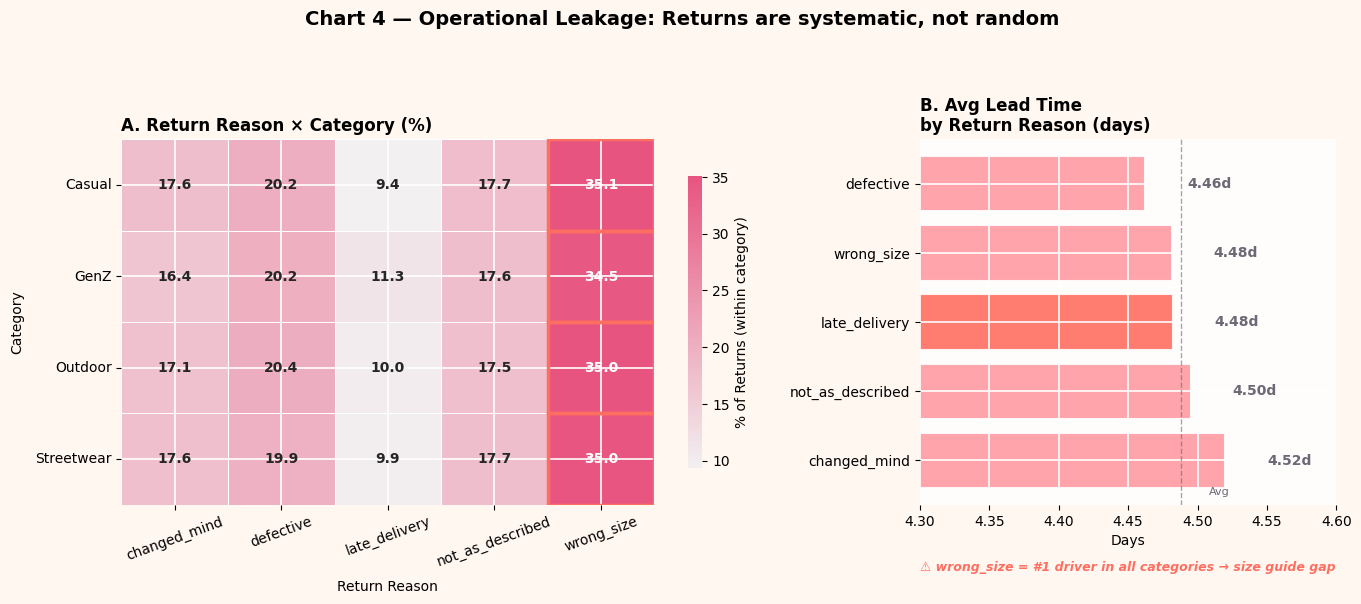

In [123]:
# ============================================================
# CHART 4 — Logistics / Return Heatmap (Diagnostic)
# "Logistics friction drives returns → operational leakage identified"
# ============================================================

# ==============================
# 1. PREP DATA
# ==============================
# Join returns → product category
ret_full = df_returns.merge(df_products[['product_id','category']], on='product_id', how='left')

# Heatmap: return reason × category (count normalized by category total)
heat_raw = ret_full.groupby(['category','return_reason'])['return_id'].count().unstack(fill_value=0)
heat_pct = heat_raw.div(heat_raw.sum(axis=1), axis=0) * 100   # % within category

# Lead time by return reason (late_delivery focus)
ship_ret = df_returns.merge(
    df_shipments[['order_id','ship_date','delivery_date']], on='order_id', how='left'
)
ship_ret['lead_time'] = (ship_ret['delivery_date'] - ship_ret['ship_date']).dt.days
lead_by_reason = ship_ret.groupby('return_reason')['lead_time'].mean().sort_values(ascending=False)

# ==============================
# 2. PLOT
# ==============================
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [1.6, 1]}
)
fig.patch.set_facecolor(BG_COLOR)

# ---- PANEL A: HEATMAP ----
ax = axes[0]
ax.set_facecolor(BG_COLOR)

cmap = sns.light_palette(PINK_DARK, as_cmap=True)
sns.heatmap(
    heat_pct,
    ax=ax,
    cmap=cmap,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '% of Returns (within category)', 'shrink': 0.8},
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title('A. Return Reason × Category (%)', loc='left', fontweight='bold', fontsize=12)
ax.set_xlabel('Return Reason', labelpad=8)
ax.set_ylabel('Category', labelpad=8)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

# Highlight max cell per row
for i, cat in enumerate(heat_pct.index):
    max_col = heat_pct.loc[cat].idxmax()
    j = list(heat_pct.columns).index(max_col)
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                edgecolor=CORAL_PEAK, lw=2.5, zorder=5))

# ---- PANEL B: BAR — Lead Time by Return Reason ----
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

colors_bar = [CORAL_PEAK if r == 'late_delivery' else PINK_MAIN for r in lead_by_reason.index]

bars = ax2.barh(
    lead_by_reason.index,
    lead_by_reason.values,
    color=colors_bar,
    alpha=0.9,
    edgecolor='white',
    linewidth=1.5
)

# Value labels
for bar, val in zip(bars, lead_by_reason.values):
    ax2.text(val + 0.03, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}d', va='center', fontsize=10, fontweight='bold', color=TEXT_GRAY)

ax2.axvline(lead_by_reason.mean(), color=TEXT_GRAY, linestyle='--', linewidth=1, alpha=0.6)
ax2.text(lead_by_reason.mean() + 0.02, -0.5, 'Avg', fontsize=8, color=TEXT_GRAY)

ax2.set_title('B. Avg Lead Time\nby Return Reason (days)', loc='left', fontweight='bold', fontsize=12)
ax2.set_xlabel('Days')
ax2.set_xlim(4.3, 4.6)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Insight annotation
ax2.text(
    0.5, -0.18,
    '⚠ wrong_size = #1 driver in all categories → size guide gap',
    transform=ax2.transAxes, ha='center', fontsize=9,
    color=CORAL_PEAK, fontweight='bold', style='italic'
)

# ---- SUPTITLE ----
plt.suptitle(
    'Chart 4 — Operational Leakage: Returns are systematic, not random',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout(pad=2.0)
plt.show()

*Nhận xét:*
- Mô hình hoàn trả giữa các danh mục có phân bố khá tương đồng, cho thấy nguyên nhân trả hàng mang tính hệ thống thay vì chỉ tập trung ở một nhóm sản phẩm cụ thể.
- `wrong_size` là lý do hoàn trả phổ biến nhất ở toàn bộ danh mục, phản ánh vấn đề xuyên suốt trong khâu quản lý kỳ vọng và sự phù hợp thị trường của doanh nghiệp.
- Thời gian giao hàng trung bình giữa các nhóm lý do hoàn trả không chênh lệch đáng kể, cho thấy lead time logistics hiện chưa phải yếu tố chính thúc đẩy hoàn trả.

$\rightarrow$ Vấn đề hoàn trả chủ yếu đến từ chất lượng thông tin sản phẩm và trải nghiệm mua hàng hơn là hiệu suất giao vận.

## 2.3. Predictive: What it likely to happen?

**Dự báo nhu cầu và hệ số vụ mùa**

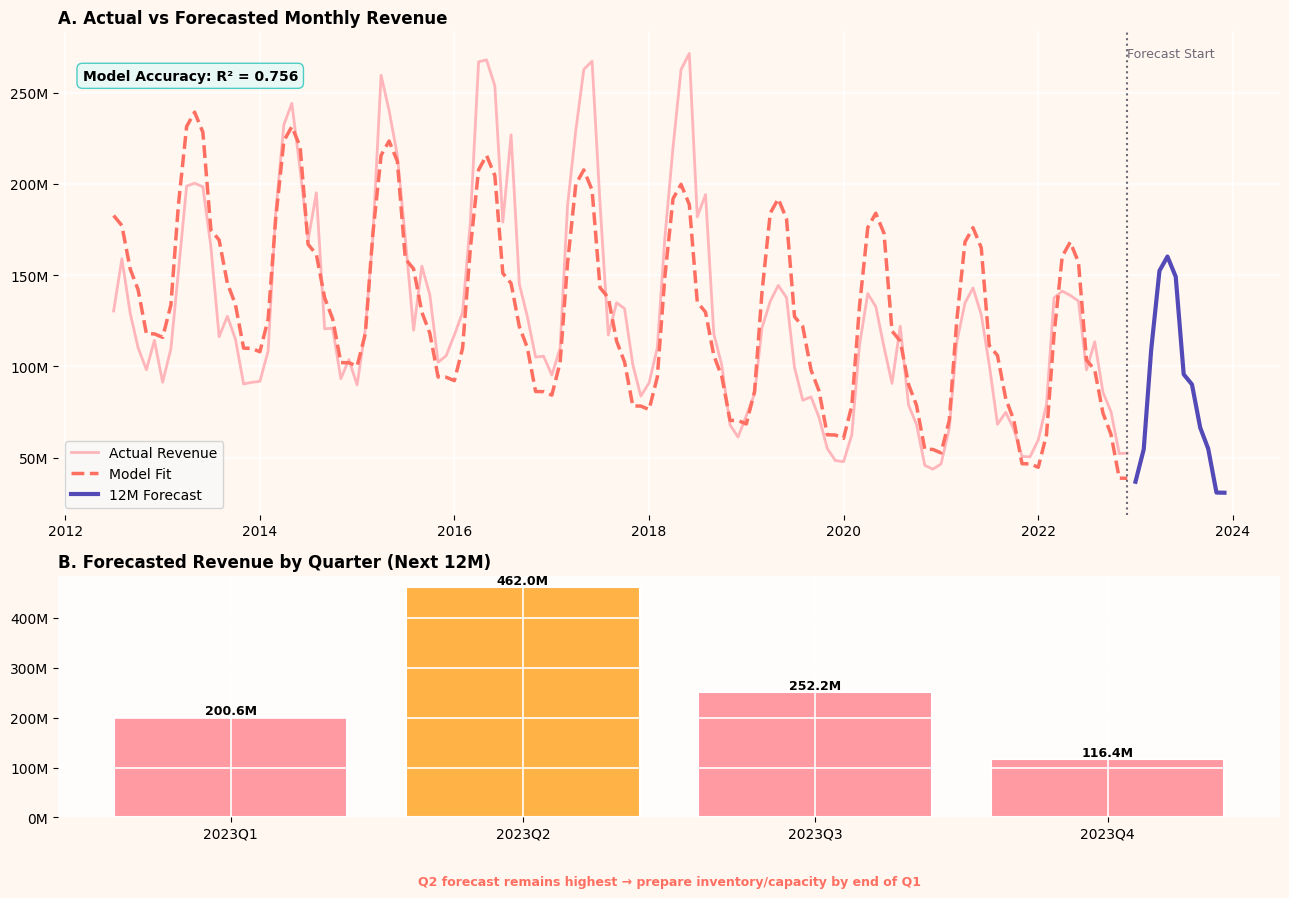

In [124]:
# ============================================================
# CHART 5 — Forecasting Demand (Predictive)
# "Model predicts future demand with seasonal pattern"
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==============================
# 1. PREP DATA
# ==============================
forecast_df = monthly_sales.copy()

forecast_df['t'] = np.arange(len(forecast_df))
forecast_df['month_num'] = forecast_df['Month'].dt.month

# One-hot encode month seasonality
month_dummies = pd.get_dummies(
    forecast_df['month_num'],
    prefix='m',
    drop_first=True
)

X = pd.concat([forecast_df[['t']], month_dummies], axis=1)
y = forecast_df['Revenue']

# ==============================
# 2. TRAIN MODEL
# ==============================
model = LinearRegression()
model.fit(X, y)

forecast_df['Predicted'] = model.predict(X)
r2 = r2_score(y, forecast_df['Predicted'])

# ==============================
# 3. FORECAST NEXT 12 MONTHS
# ==============================
future_periods = 12
future_t = np.arange(len(forecast_df), len(forecast_df)+future_periods)

future_dates = pd.date_range(
    start=forecast_df['Month'].max() + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq='MS'
)

future_month = future_dates.month

future_dummies = pd.get_dummies(
    future_month,
    prefix='m'
).reindex(columns=month_dummies.columns, fill_value=0)

X_future = pd.concat([
    pd.DataFrame({'t': future_t}),
    future_dummies.reset_index(drop=True)
], axis=1)

future_pred = model.predict(X_future)

future_df = pd.DataFrame({
    'Month': future_dates,
    'Forecast': future_pred
})

# ==============================
# 4. QUARTERLY AGG
# ==============================
future_df['Quarter'] = future_df['Month'].dt.to_period('Q')
quarter_forecast = future_df.groupby('Quarter')['Forecast'].sum().reset_index()
quarter_forecast['Quarter'] = quarter_forecast['Quarter'].astype(str)

# ==============================
# 5. PLOT
# ==============================
fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 9),
    gridspec_kw={'height_ratios':[2,1]}
)

fig.patch.set_facecolor(BG_COLOR)

# ------------------------------
# PANEL A — Actual vs Forecast
# ------------------------------
ax = axes[0]
ax.set_facecolor(BG_COLOR)

ax.plot(
    forecast_df['Month'],
    forecast_df['Revenue'],
    color=PINK_MAIN,
    linewidth=2,
    alpha=0.7,
    label='Actual Revenue'
)

ax.plot(
    forecast_df['Month'],
    forecast_df['Predicted'],
    color=CORAL_PEAK,
    linewidth=2.5,
    linestyle='--',
    label='Model Fit'
)

ax.plot(
    future_df['Month'],
    future_df['Forecast'],
    color=PURPLE,
    linewidth=3,
    label='12M Forecast'
)

ax.axvline(
    forecast_df['Month'].max(),
    color=TEXT_GRAY,
    linestyle=':',
    linewidth=1.5
)

ax.text(
    forecast_df['Month'].max(),
    ax.get_ylim()[1]*0.95,
    'Forecast Start',
    fontsize=9,
    color=TEXT_GRAY
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

ax.set_title(
    'A. Actual vs Forecasted Monthly Revenue',
    loc='left',
    fontweight='bold'
)

ax.legend()

# R² annotation
ax.text(
    0.02, 0.90,
    f'Model Accuracy: R² = {r2:.3f}',
    transform=ax.transAxes,
    fontsize=10,
    fontweight='bold',
    bbox=dict(
        boxstyle='round,pad=0.4',
        fc='#E8F8F5',
        ec='#4ECDC4'
    )
)

# ------------------------------
# PANEL B — Quarterly Forecast
# ------------------------------
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

bars = ax2.bar(
    quarter_forecast['Quarter'],
    quarter_forecast['Forecast'],
    color=[
        YELLOW_HL if 'Q2' in q else PINK_MAIN
        for q in quarter_forecast['Quarter']
    ],
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, quarter_forecast['Forecast']):
    ax2.text(
        bar.get_x()+bar.get_width()/2,
        val,
        f'{val/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title(
    'B. Forecasted Revenue by Quarter (Next 12M)',
    loc='left',
    fontweight='bold'
)

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

ax2.text(
    0.5, -0.28,
    'Q2 forecast remains highest → prepare inventory/capacity by end of Q1',
    transform=ax2.transAxes,
    ha='center',
    fontsize=9,
    color=CORAL_PEAK,
    fontweight='bold'
)

for axx in axes:
    for spine in ['top','right']:
        axx.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

*Nhận xét:*
- Mô hình dự báo xác nhận quý 2 tiếp tục là giai đoạn nhu cầu cao điểm, cho thấy yếu tố mùa vụ có tính lặp lại và có thể dự báo.
- Các tháng cao điểm có hệ số mùa vụ (seasonal multiplier) vượt đáng kể mức nền, cho thấy doanh thu thường cao hơn xu hướng cơ sở khoảng 30–50%.
- Tuy nhiên, xu hướng nền (baseline trend) không tăng tương ứng, hàm ý doanh nghiệp đang phụ thuộc nhiều vào mùa cao điểm thay vì tăng trưởng ổn định quanh năm.

$\rightarrow$ Cần chuẩn bị tồn kho, năng lực vận hành và ngân sách marketing trước giai đoạn cao điểm.

## 2.4. Prescriptive: What should we do?

**Tác động cháy hàng đến hiệu quả tồn kho**

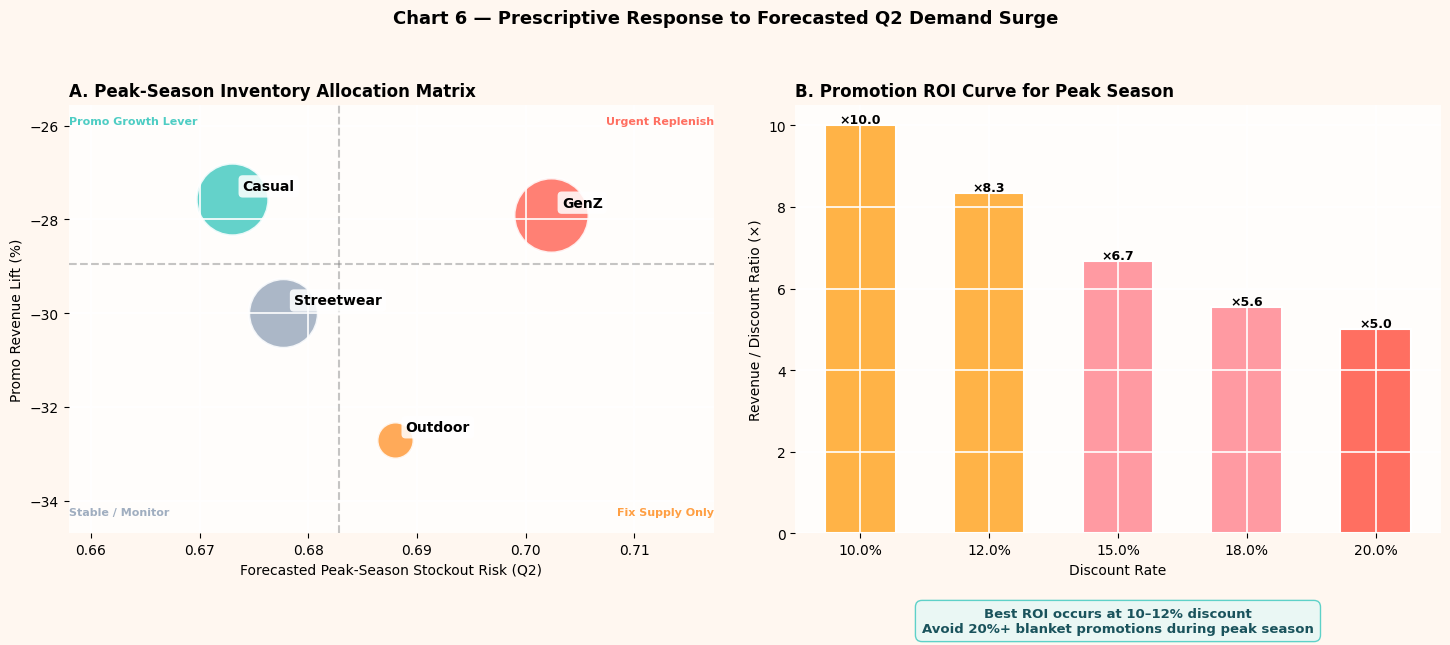

In [125]:
# ============================================================
# CHART 6 — Forecast-Informed Inventory & Promo Allocation
# Prescriptive Response to Forecasted Q2 Demand Surge
# ============================================================

# ==============================
# 1. PREP DATA
# ==============================

# Ensure category exists
if 'category' not in oi_full.columns:
    oi_full = oi_full.merge(
        df_products[['product_id', 'category']],
        on='product_id',
        how='left'
    )

# ------------------------------
# Promo Lift by Category
# ------------------------------
oi_with = (
    oi_full[oi_full['promo_id'].notna()]
    .groupby('category')['revenue']
    .mean()
    .rename('rev_with')
)

oi_wo = (
    oi_full[oi_full['promo_id'].isna()]
    .groupby('category')['revenue']
    .mean()
    .rename('rev_without')
)

promo_lift = pd.concat([oi_with, oi_wo], axis=1).reset_index()
promo_lift['lift_pct'] = (
    promo_lift['rev_with'] / promo_lift['rev_without'] - 1
) * 100


# ------------------------------
# Forecast-based Peak Season Risk (Q2)
# ------------------------------
inv_with_cat = df_inventory.drop(
    columns=['category', 'segment'],
    errors='ignore'
).merge(
    df_products[['product_id', 'category', 'segment']],
    on='product_id',
    how='left'
)

inv_q2 = (
    inv_with_cat[inv_with_cat['month'].isin([4, 5, 6])]
    .groupby('category')
    .agg(
        stockout_rate=('stockout_flag', 'mean'),
        sell_through=('sell_through_rate', 'mean')
    )
    .reset_index()
)

# ------------------------------
# Merge Matrix
# ------------------------------
matrix = promo_lift.merge(inv_q2, on='category')

rate_mid = matrix['stockout_rate'].median()
lift_mid = matrix['lift_pct'].median()


def assign_quadrant(row):
    high_stock = row['stockout_rate'] >= rate_mid
    high_lift  = row['lift_pct'] >= lift_mid

    if high_stock and high_lift:
        return 'Urgent Replenish', CORAL_PEAK

    if high_stock and not high_lift:
        return 'Fix Supply Only', '#FF9F43'

    if not high_stock and high_lift:
        return 'Promo Growth Lever', '#4ECDC4'

    return 'Stable / Monitor', '#A0AEC0'


matrix[['quadrant', 'color']] = matrix.apply(
    lambda r: pd.Series(assign_quadrant(r)),
    axis=1
)

# Bubble Size
size_scale = (
    (matrix['sell_through'] - matrix['sell_through'].min()) /
    (matrix['sell_through'].max() - matrix['sell_through'].min() + 1e-6)
)

matrix['bubble_size'] = size_scale * 2200 + 700


# ------------------------------
# Promo ROI by Discount
# ------------------------------
promo_eff = df_order_items.copy()

promo_eff = promo_eff[
    promo_eff['promo_id'].notna()
].merge(
    df_promotions[['promo_id', 'discount_value']],
    on='promo_id'
)

promo_eff['revenue'] = (
    promo_eff['quantity'] * promo_eff['unit_price']
)

eff_by_disc = (
    promo_eff.groupby('discount_value')
    .agg(
        total_rev=('revenue', 'sum'),
        total_disc=('discount_amount', 'sum'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

eff_by_disc['roi'] = (
    eff_by_disc['total_rev'] /
    (eff_by_disc['total_disc'] + 1)
)

eff_by_disc = eff_by_disc[
    eff_by_disc['discount_value'] != 50
]


# ==============================
# 2. PLOT
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(BG_COLOR)


# ============================================================
# PANEL A — Peak Season Allocation Matrix
# ============================================================
ax = axes[0]
ax.set_facecolor('#FFFDFB')

ax.axvline(rate_mid, linestyle='--', color='gray', alpha=0.45)
ax.axhline(lift_mid, linestyle='--', color='gray', alpha=0.45)

for _, row in matrix.iterrows():

    ax.scatter(
        row['stockout_rate'],
        row['lift_pct'],
        s=row['bubble_size'],
        color=row['color'],
        alpha=0.88,
        edgecolors='white',
        linewidth=2
    )

    ax.annotate(
        row['category'],
        (row['stockout_rate'], row['lift_pct']),
        xytext=(8, 6),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='none',
            alpha=0.85
        )
    )

ax.set_xlim(
    matrix['stockout_rate'].min() - 0.015,
    matrix['stockout_rate'].max() + 0.015
)

ax.set_ylim(
    matrix['lift_pct'].min() - 2,
    matrix['lift_pct'].max() + 2
)

xl, xr = ax.get_xlim()
yb, yt = ax.get_ylim()

ax.text(xr, yt-0.4, 'Urgent Replenish',
        ha='right', fontsize=8, color=CORAL_PEAK, fontweight='bold')

ax.text(xl, yt-0.4, 'Promo Growth Lever',
        ha='left', fontsize=8, color='#4ECDC4', fontweight='bold')

ax.text(xr, yb+0.4, 'Fix Supply Only',
        ha='right', fontsize=8, color='#FF9F43', fontweight='bold')

ax.text(xl, yb+0.4, 'Stable / Monitor',
        ha='left', fontsize=8, color='#A0AEC0', fontweight='bold')

ax.set_xlabel('Forecasted Peak-Season Stockout Risk (Q2)')
ax.set_ylabel('Promo Revenue Lift (%)')

ax.set_title(
    'A. Peak-Season Inventory Allocation Matrix',
    loc='left',
    fontweight='bold'
)


# ============================================================
# PANEL B — Promo ROI Curve
# ============================================================
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

bar_colors = [
    YELLOW_HL if d <= 12 else
    PINK_MAIN if d <= 18 else
    CORAL_PEAK
    for d in eff_by_disc['discount_value']
]

bars = ax2.bar(
    eff_by_disc['discount_value'].astype(str) + '%',
    eff_by_disc['roi'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.55
)

for bar, roi in zip(bars, eff_by_disc['roi']):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        roi + 0.05,
        f'×{roi:.1f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title(
    'B. Promotion ROI Curve for Peak Season',
    loc='left',
    fontweight='bold'
)

ax2.set_xlabel('Discount Rate')
ax2.set_ylabel('Revenue / Discount Ratio (×)')


# Insight Box
ax2.text(
    0.5, -0.23,
    'Best ROI occurs at 10–12% discount\n'
    'Avoid 20%+ blanket promotions during peak season',
    transform=ax2.transAxes,
    ha='center',
    fontsize=9.5,
    fontweight='bold',
    color='#1A535C',
    bbox=dict(
        boxstyle='round,pad=0.5',
        fc='#E8F8F5',
        ec='#4ECDC4',
        alpha=0.9
    )
)


# Clean
for a in axes:
    for spine in ['top', 'right']:
        a.spines[spine].set_visible(False)


plt.suptitle(
    'Chart 6 — Prescriptive Response to Forecasted Q2 Demand Surge',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout(pad=2.5)
plt.show()

**Nhận xét:**
- Một số danh mục có rủi ro hết hàng cao và có phản ứng tốt nếu có chương trình khuyến mãi, cần được ưu tiên bổ sung tồn kho trước mùa cao điểm.
- Một số danh mục có rủi ro thiếu hàng nhưng hiệu quả khuyến mãi thấp, cho thấy cần xử lý vấn đề cung ứng trước khi tăng ngân sách marketing.
- Hiệu quả khuyến mãi đạt tối ưu ở mức giảm giá 10–12%; giảm giá sâu hơn cho thấy lợi suất giảm dần rõ rệt.

$\rightarrow$ Phân bổ tồn kho và khuyến mãi theo từng danh mục, đồng thời giới hạn giảm giá sâu trong mùa cao điểm.